## 2 概述、线性代数和 NDArray

### 2.1 理论计算题

已知：
- a = [2, -1, 3]^T
- b = [1, 4, -2]^T
- A = [[1, 0, 2], [-1, 3, 1]]
- B = [[2, 1], [0, -1], [3, 2]]

1. 向量点积：
   a·b = 2×1 + (-1)×4 + 3×(-2) = -8

2. 矩阵乘法：
   AB = [[8, 5], [1, -2]]
   结果矩阵形状为 (2, 2)

3. 向量 a 的 Frobenius 范数（对向量等于 2 范数）：
   ||a|| = sqrt(2^2 + (-1)^2 + 3^2) = sqrt(14)

In [5]:

import numpy as np

print("=== 2.2 编程题：NumPy 基础操作 ===")
np.random.seed(42)

# 1. 创建一个 3x4 的标准正态随机矩阵 X
X = np.random.randn(3, 4)
print("X =")
print(X)
print("X.shape =", X.shape)

# 2. 创建一个 4x2 的全 1 矩阵 Y
Y = np.ones((4, 2))
print("\nY =")
print(Y)
print("Y.shape =", Y.shape)

# 3. 矩阵乘法 Z = X @ Y
Z = X @ Y
print("\nZ = X @ Y =")
print(Z)
print("Z.shape =", Z.shape)

# 4. 输出指定元素
print("\nZ 第一行第二列元素 Z[0, 1] =", Z[0, 1])
print("Z 第 2 行所有元素 Z[1, :] =", Z[1, :])

# 5. Frobenius 范数
fro_z = np.linalg.norm(Z, ord="fro")
print("\nZ 的 Frobenius 范数 =", fro_z)


=== 2.2 编程题：NumPy 基础操作 ===
X =
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]
X.shape = (3, 4)

Y =
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Y.shape = (4, 2)

Z = X @ Y =
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]
Z.shape = (3, 2)

Z 第一行第二列元素 Z[0, 1] = 2.5291682463487657
Z 第 2 行所有元素 Z[1, :] = [1.87835721 1.87835721]

Z 的 Frobenius 范数 = 4.616873319476863


## 3 概率与统计

### 3.1 理论计算题

设：
- P(患病) = 0.001
- P(阳性 | 患病) = 0.99
- P(阳性 | 未患病) = 0.02

根据贝叶斯公式：

P(患病 | 阳性) = P(阳性 | 患病) × P(患病) / P(阳性)

其中：

P(阳性) = 0.99 × 0.001 + 0.02 × 0.999 = 0.02097

所以：

P(患病 | 阳性) = 0.99 × 0.001 / 0.02097 ≈ 0.0472

即：检测阳性后，真正患病的概率约为 4.72%。

=== 3.2 编程题：中心极限定理模拟 ===
均值样本前 10 个： [0.49415956 0.50452988 0.50005039 0.49871338 0.49686381 0.50314459
 0.50178812 0.49922448 0.50104335 0.49536495]
实际方差 = 8.275637010510702e-06
理论方差 = 8.333333333333332e-06


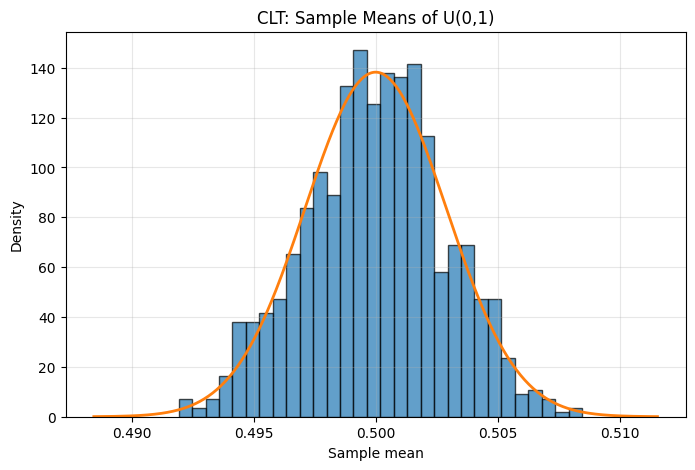

In [6]:

import numpy as np
import matplotlib.pyplot as plt

print("=== 3.2 编程题：中心极限定理模拟 ===")
np.random.seed(42)

n = 10000
m = 1000

# 生成 m 组，每组 n 个 U(0,1) 随机变量，并计算每组均值
samples = np.random.uniform(0, 1, size=(m, n))
means = samples.mean(axis=1)

# 理论参数
mu = 0.5
sigma = np.sqrt((1/12) / n)

# 实际方差
actual_var = np.var(means, ddof=0)
print("均值样本前 10 个：", means[:10])
print("实际方差 =", actual_var)
print("理论方差 =", (1/12) / n)

# 画图
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf = 1 / (np.sqrt(2*np.pi) * sigma) * np.exp(-((x - mu)**2) / (2*sigma**2))

plt.figure(figsize=(8, 5))
plt.hist(means, bins=30, density=True, alpha=0.7, edgecolor="black")
plt.plot(x, pdf, linewidth=2)
plt.title("CLT: Sample Means of U(0,1)")
plt.xlabel("Sample mean")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()


## 4 导数、反向传播和复杂度

### 4.1 理论计算题

给定：z = (w1*x1 + w2*x2 - y)^2，其中 x1 = 2, x2 = 1, y = 3。

记 u = w1*x1 + w2*x2 - y，则 z = u^2。

由链式法则：
- ∂z/∂w1 = 2u × ∂u/∂w1 = 2(w1*x1 + w2*x2 - y) × x1
- ∂z/∂w2 = 2u × ∂u/∂w2 = 2(w1*x1 + w2*x2 - y) × x2

代入 x1 = 2, x2 = 1：
- ∂z/∂w1 = 4(2w1 + w2 - 3)
- ∂z/∂w2 = 2(2w1 + w2 - 3)

若 w1 = 0.5, w2 = 1，则：
- 2w1 + w2 - 3 = 1 + 1 - 3 = -1
- ∂z/∂w1 = -4
- ∂z/∂w2 = -2

In [7]:

import torch

print("=== 4.2 编程题：手动反向传播 ===")

# 给定参数
x = 2.0
w1 = 1.5
w2 = 0.5

# 前向传播
a = x * w1
b = a + w2
L = b ** 2

print("前向计算结果：")
print("a =", a)
print("b =", b)
print("L =", L)

# 手动求导
# L = b^2, dL/db = 2b
# b = x*w1 + w2
# dL/dw1 = dL/db * db/dw1 = 2b * x
# dL/dw2 = dL/db * db/dw2 = 2b * 1
grad_w1_manual = 2 * b * x
grad_w2_manual = 2 * b

print("\n手动计算梯度：")
print("dL/dw1 =", grad_w1_manual)
print("dL/dw2 =", grad_w2_manual)

# 自动微分验证
x_t = torch.tensor(2.0)
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print("\n自动微分结果：")
print("dL/dw1 =", w1_t.grad.item())
print("dL/dw2 =", w2_t.grad.item())


=== 4.2 编程题：手动反向传播 ===
前向计算结果：
a = 3.0
b = 3.5
L = 12.25

手动计算梯度：
dL/dw1 = 14.0
dL/dw2 = 7.0

自动微分结果：
dL/dw1 = 14.0
dL/dw2 = 7.0


## 5 线性方法、基础优化和 Softmax 回归

### 5.1 理论计算题

线性回归模型：y = wx + b

均方误差损失：

L = (1/n) * Σ(yi - (wxi + b))^2

对 w 求偏导：

∂L/∂w = (2/n) * Σ[(wxi + b - yi) * xi]

对 b 求偏导：

∂L/∂b = (2/n) * Σ(wxi + b - yi)

In [8]:

import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

print("=== 5.2 编程题：从零实现 Softmax 回归 ===")
np.random.seed(42)

# 1. 加载数据
digits = load_digits()
X = digits.data / 16.0  # 归一化
y = digits.target

# 2. one-hot 编码
num_classes = 10
Y = np.eye(num_classes)[y]

X_train, X_test, Y_train, Y_test, y_train, y_test = train_test_split(
    X, Y, y, test_size=0.2, random_state=42, stratify=y
)

# 参数初始化
n_features = X_train.shape[1]
W = 0.01 * np.random.randn(n_features, num_classes)
b = np.zeros((1, num_classes))

def softmax(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def cross_entropy(y_pred, y_true):
    eps = 1e-12
    return -np.mean(np.sum(y_true * np.log(y_pred + eps), axis=1))

# 训练
lr = 0.1
batch_size = 32
epochs = 50
n_train = X_train.shape[0]

for epoch in range(epochs):
    indices = np.random.permutation(n_train)
    X_train_shuf = X_train[indices]
    Y_train_shuf = Y_train[indices]

    for start in range(0, n_train, batch_size):
        end = start + batch_size
        xb = X_train_shuf[start:end]
        yb = Y_train_shuf[start:end]

        logits = xb @ W + b
        probs = softmax(logits)
        loss = cross_entropy(probs, yb)

        # 梯度
        grad_logits = (probs - yb) / xb.shape[0]
        grad_W = xb.T @ grad_logits
        grad_b = np.sum(grad_logits, axis=0, keepdims=True)

        # 更新
        W -= lr * grad_W
        b -= lr * grad_b

    if (epoch + 1) % 10 == 0:
        train_probs = softmax(X_train @ W + b)
        train_loss = cross_entropy(train_probs, Y_train)
        train_pred = np.argmax(train_probs, axis=1)
        train_acc = np.mean(train_pred == y_train)
        print(f"Epoch {epoch+1:02d}: loss={train_loss:.4f}, train_acc={train_acc:.4f}")

# 测试集准确率
test_probs = softmax(X_test @ W + b)
test_pred = np.argmax(test_probs, axis=1)
test_acc = np.mean(test_pred == y_test)
print("\n测试集准确率 =", test_acc)


=== 5.2 编程题：从零实现 Softmax 回归 ===
Epoch 10: loss=0.4377, train_acc=0.9374
Epoch 20: loss=0.2920, train_acc=0.9534
Epoch 30: loss=0.2350, train_acc=0.9589
Epoch 40: loss=0.2021, train_acc=0.9617
Epoch 50: loss=0.1806, train_acc=0.9673

测试集准确率 = 0.9527777777777777


## 6 最大似然估计和逻辑回归

### 6.1 理论计算题

设样本 x1, x2, ..., xn 独立同分布于正态分布 N(μ, σ²)。

1. 似然函数：

L(μ, σ²) = ∏ [1 / sqrt(2πσ²)] * exp(-(xi - μ)^2 / (2σ²))

即：

L(μ, σ²) = (1 / sqrt(2πσ²))^n * exp(- Σ(xi - μ)^2 / (2σ²))

2. 对数似然函数对 μ 求偏导并令其为 0，可得：

μ_hat = (1/n) * Σxi

3. 将 μ_hat 代回，对 σ² 求偏导并令其为 0，可得：

σ²_hat = (1/n) * Σ(xi - μ_hat)^2

=== 6.2 编程题：从零实现二分类逻辑回归 ===
Epoch 0200: loss=0.0208, train_acc=0.9975
Epoch 0400: loss=0.0139, train_acc=0.9975
Epoch 0600: loss=0.0111, train_acc=0.9975
Epoch 0800: loss=0.0095, train_acc=0.9975
Epoch 1000: loss=0.0085, train_acc=0.9975

测试集准确率 = 0.99


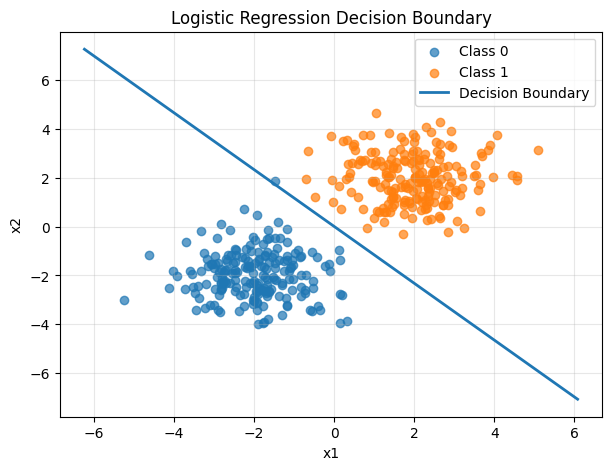

In [9]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

print("=== 6.2 编程题：从零实现二分类逻辑回归 ===")
np.random.seed(42)

# 1. 生成线性可分数据
X_train, y_train = make_blobs(
    n_samples=400, centers=[(-2, -2), (2, 2)],
    cluster_std=1.0, n_features=2, random_state=42
)
y_train = y_train.reshape(-1, 1)

# 测试集
X_test, y_test = make_blobs(
    n_samples=100, centers=[(-2, -2), (2, 2)],
    cluster_std=1.0, n_features=2, random_state=123
)
y_test = y_test.reshape(-1, 1)

# 2. sigmoid 和 BCE
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_hat, y):
    eps = 1e-12
    return -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

# 3. 梯度下降
n_samples, n_features = X_train.shape
w = np.zeros((n_features, 1))
b = 0.0

lr = 0.1
epochs = 1000

for epoch in range(epochs):
    z = X_train @ w + b
    y_hat = sigmoid(z)

    loss = binary_cross_entropy(y_hat, y_train)

    dw = (X_train.T @ (y_hat - y_train)) / n_samples
    db = np.mean(y_hat - y_train)

    w -= lr * dw
    b -= lr * db

    if (epoch + 1) % 200 == 0:
        preds = (y_hat >= 0.5).astype(int)
        acc = np.mean(preds == y_train)
        print(f"Epoch {epoch+1:04d}: loss={loss:.4f}, train_acc={acc:.4f}")

# 4. 测试集准确率
test_probs = sigmoid(X_test @ w + b)
test_preds = (test_probs >= 0.5).astype(int)
test_acc = np.mean(test_preds == y_test)
print("\n测试集准确率 =", test_acc)

# 绘制决策边界
plt.figure(figsize=(7, 5))
plt.scatter(X_train[y_train[:, 0] == 0, 0], X_train[y_train[:, 0] == 0, 1], label="Class 0", alpha=0.7)
plt.scatter(X_train[y_train[:, 0] == 1, 0], X_train[y_train[:, 0] == 1, 1], label="Class 1", alpha=0.7)

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
xs = np.linspace(x_min, x_max, 200)

# w0*x + w1*y + b = 0 => y = -(w0*x + b)/w1
if abs(w[1, 0]) > 1e-12:
    ys = -(w[0, 0] * xs + b) / w[1, 0]
    plt.plot(xs, ys, linewidth=2, label="Decision Boundary")

plt.title("Logistic Regression Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
